<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW5_boosting_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашняя работа: прогнозирование заработной платы и кластеризация типов движений**

### **Постановка задачи:**

В этой работе две части:

*   В первой части вам предстоит построить алгоритм на основе бустинга для прогнозирования зарплаты
*   Во второй части вам предстоит кластеризовать типы движений по имеющимся данным с акселерометров и гироскопов

### **Оценивание:**

- Как всегда оцениваются как код, так и ответы на вопросы. Если нет одного и/или другого, то часть баллов за соответствующее задание без колебаний снимается.
- Брать код из открытых источников позволительно. Следование культуре цитирования **обязательно.**

### **Баллы:**

Суммарно за задание можно получить 10 основных и 1 бонусный балл.

Оценка за ДЗ = min{ваш балл, 10}

**Интересной вам работы!**


# **Часть 1. Прогнозирование заработной платы при помощи бустинга**

**Количество баллов:** 7

## **Постановка задачи:**

Данные выгружены и лежат в файле `ds_salary.csv`. Вам доступны описания признаков и значения целевой переменной.

**Ваша задача:** построение модели бустинга и оценка данной модели.

## **Описание даных**

- work_year: год, в который взяты данные;
- experience_level: уровень опыта, кодируемый как SE, MI EN или EX
- employment_type: тип занятости (FT, PT, CT, FL)
- job_title: название рабочей позиции в компании;
- salary: зараплата на позиции;
- salary_currency: валюта в которой начисляют зарплату;
- employee_residence: страна или регион проживания сотрудника
- remote_ratio: процент удаленки, предлагаемый в компании (0, 50, 100)
- company_location: местоположение компании
- company_size: размер компании, оцененный как S, M, L
- salary_in_usd: целевая переменная


Как всегда, загрузим набор данных.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("https://github.com/hse-ds/iad-intro-ds/raw/refs/heads/master/2023/homeworks/hw-08-boosting/ds_salaries.csv")

## **Задание 1 (0.3 балла)**

Вам даны описания переменных. Проверьте, что категориальные признаки, категории которых перечислены, не имеют ошибочных значений. Для этого:

- Напишите цикл, пробегающий по выбранным признакам и оценивающий, что в них нет лишних значений;

In [4]:
print(df['job_title'].isna().sum())
print(df['salary_currency'].isna().sum())
print(df['employee_residence'].isna().sum())
print(df['company_location'].isna().sum())

0
0
0
0


In [5]:
# Ваш код здесь
exp_lvl_values = ['SE', 'MI', 'EN', 'EX']
emp_type_values = ['FT', 'PT', 'CT', 'FL']
company_size_values = ['S', 'M', 'L']

cat_cols = [x for x in df.columns if df[x].dtypes == 'object']
for i_cat_col in cat_cols:
    if i_cat_col == 'experience_level':
        for value in df[i_cat_col]:
            if value not in exp_lvl_values:
                print(f"найдено лишнее значение {value} в {i_cat_col}")
    elif i_cat_col == 'employment_type':
        for value in df[i_cat_col]:
            if value not in emp_type_values:
                print(f"найдено лишнее значение {value} в {i_cat_col}")
    elif i_cat_col == 'company_size':
        for value in df[i_cat_col]:
            if value not in company_size_values:
                print(f"найдено лишнее значение {value} в {i_cat_col}")

неверных значений нет.

## **Задание 2 (0.3 балла)**

Проведите базовые шаги оценки качества данных.
- Есть есть проблемы, устраните их;
- Если нет проблем, кратко опишите это.

In [6]:
df.describe().round(4)

,work_year,salary,salary_in_usd,remote_ratio
count,3755.0000,3.755000e+03,3755.0000,3755.0000
mean,2022.3736,1.906956e+05,137570.3899,46.2716
std,0.6914,6.716765e+05,63055.6253,48.5891
min,2020.0000,6.000000e+03,5132.0000,0.0000
25%,2022.0000,1.000000e+05,95000.0000,0.0000
50%,2022.0000,1.380000e+05,135000.0000,0.0000
75%,2023.0000,1.800000e+05,175000.0000,100.0000
max,2023.0000,3.040000e+07,450000.0000,100.0000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [8]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [9]:
# Ваш код здесь
df.isna().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

<Axes: >

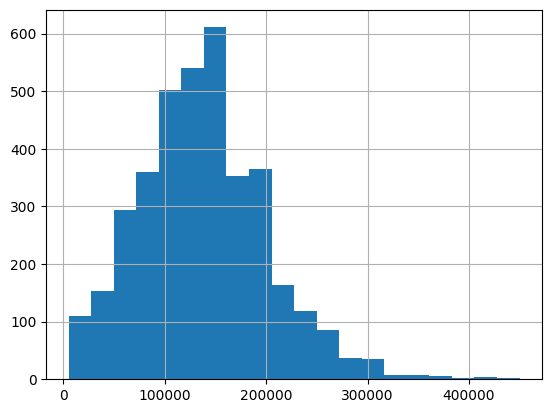

In [10]:
df['salary_in_usd'].hist(bins=20)

In [11]:
print('yes' if "True" in str(df.duplicated()) else 'no')


no


<Axes: >

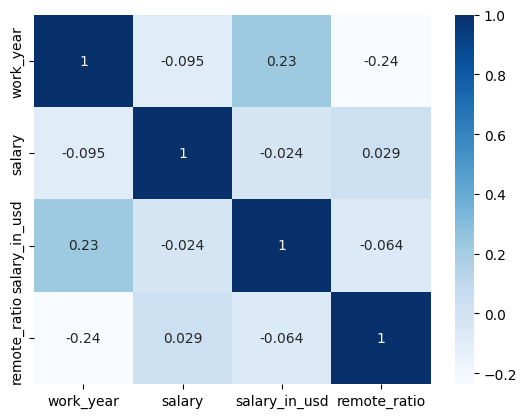

In [12]:
import seaborn as sns

num_cols = [x for x in df.columns if df[x].dtypes == 'float64' or df[x].dtypes == 'int64']
sns.heatmap(df[num_cols].corr(), cmap='Blues', annot=True)

Данные без пропусков, без очеведных выбросов, целевая переменная имеет распределение близкое к нормальному, данные отображаются в верном формате, целевая переменная имеет линейную взаимосвязь с признаками, использование моделей ML обосновано.

## **Задание 3 (0.3 балла)**

Вернитесь к описанию признаков.
- Проверьте, все ли признаки соответствуют постановке задачи? Если есть лишние признаки, удалите их и обоснуйте удаление, если нет, сделайте вывод о релевантности (достаточно в одну-две строки)
- Зафиксируйте, в каких признаках много категорий.

In [13]:
# Ваш код здесь
for i in cat_cols:
    print(f'количество уникальных значений признака {i} = {df[i].nunique()}')

количество уникальных значений признака experience_level = 4
количество уникальных значений признака employment_type = 4
количество уникальных значений признака job_title = 93
количество уникальных значений признака salary_currency = 20
количество уникальных значений признака employee_residence = 78
количество уникальных значений признака company_location = 72
количество уникальных значений признака company_size = 3


In [14]:
df.drop('salary', axis=1, inplace=True)

In [15]:
df.drop('salary_currency', axis=1, inplace=True)

In [16]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary_in_usd', 'employee_residence', 'remote_ratio',
       'company_location', 'company_size'],
      dtype='object')

**Ваши выводы здесь** Много категорий в признаках, job_title, employee_residence, company_location. Признак salary нерелевантен, так как он дублирует информацию о целевой переменной в другой валюте, то есть его использование приведет к утечке данных. Признак salary_currency так же не имеет значения, так как целевая переменная указана в определенной валюте, то есть построение модели будет в масштабе указанной валюты (usd).

## **Задание 4 (0.2 балла)**

Разделите выборку на train, test (80%, 20%).

In [17]:
# Ваш код здесь
from sklearn.model_selection import train_test_split

y = df['salary_in_usd']
X = df.drop('salary_in_usd', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## **Задание 5 (0.3 балла)**

Будем проверять два сценария. Первый — построение модели только на непрерывных признаках, а второй — построение с категориальными. В этом задании подготовьте всё, чтобы проверить валидность обоих сценариев. А именно:

- Выделите данные для тренировки и теста для непрерывных признаков
- Выделите данные для тренировки и теста для непрерывных + категориальных признаков, пока ничего не кодируйте.

In [18]:
# Ваш код здесь
cont_cols = [x for x in X_train.columns if X_train[x].dtypes == 'int64' or X_train[x].dtypes == 'float64']
cat_cols = list(set(X_train.columns) - set(cont_cols))

## **Задание 6 (0.2 балла)**

- Обучите модель линейной регресии на числовых признаках и оцените её качество через mape и rmse;
- Сделайте вывод о качестве построенной модели;

In [19]:
y_train.describe()

count      3004.000000
mean     138055.989348
std       63102.221140
min        5132.000000
25%       95000.000000
50%      135000.000000
75%      176250.000000
max      450000.000000
Name: salary_in_usd, dtype: float64

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import root_mean_squared_error as rmse

linreg = LinearRegression()
linreg.fit(X_train[cont_cols], y_train)
prediction = linreg.predict(X_test[cont_cols])

print(f'mape = {mape(y_test, prediction)}')
print(f'rmse = {rmse(y_test, prediction)}')



mape = 0.7064831381019816
rmse = 61358.939091178094


Качество низкое, модель плохо предсказывает. Видно, что rmse показывает ошибку в 61358, что очень близко к std на тестовых данных (std=63102). Таким образом, модель предсказывает даже чуть хуже, чем константное предсказание средним. MAPE показывает точность в 0.706, что является низким качеством.

## **Задание 8 (0.2 балла)**

- Обучите модель бустинга (любую из трех библиотек catboost, xgboost, lightgbm) с гиперпараметрами по умолчанию на непрерывных признаках и оцените её качество через mape и rmse;
- Сделайте вывод о качестве построенной модели;

In [21]:
# Ваш код здесь
from catboost import CatBoostRegressor

catboost = CatBoostRegressor().fit(X_train[cont_cols], y_train)
y_pred_catb = catboost.predict(X_test[cont_cols])

print(f'mape = {mape(y_test, y_pred_catb)}')
print(f'rmse = {rmse(y_test, y_pred_catb)}')


Learning rate set to 0.048714
0:	learn: 62828.5461530	total: 148ms	remaining: 2m 27s
1:	learn: 62588.0953074	total: 149ms	remaining: 1m 14s
2:	learn: 62436.5741770	total: 149ms	remaining: 49.6s
3:	learn: 62227.1178803	total: 150ms	remaining: 37.3s
4:	learn: 62036.1530466	total: 150ms	remaining: 29.9s
5:	learn: 61862.0934488	total: 151ms	remaining: 25s
6:	learn: 61780.4664336	total: 151ms	remaining: 21.4s
7:	learn: 61629.1862407	total: 152ms	remaining: 18.8s
8:	learn: 61491.3706390	total: 152ms	remaining: 16.8s
9:	learn: 61430.0570397	total: 152ms	remaining: 15.1s
10:	learn: 61349.4794169	total: 153ms	remaining: 13.7s
11:	learn: 61236.8041046	total: 153ms	remaining: 12.6s
12:	learn: 61176.0648370	total: 154ms	remaining: 11.7s
13:	learn: 61078.9817605	total: 154ms	remaining: 10.9s
14:	learn: 61028.8918358	total: 155ms	remaining: 10.2s
15:	learn: 60953.3530876	total: 155ms	remaining: 9.53s
16:	learn: 60922.0770465	total: 155ms	remaining: 8.98s
17:	learn: 60882.7698351	total: 156ms	remaini

Качество модели немного улучшилось, но все так же осталось посредственным.

## **Задание 9 (0.8 балла)**

Теперь подключим категориальные признаки. Но попробуем разные стратегии предобработки.

**1:**
- Предобработайте категориальные признаки при помощи OHE
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

**2:**
- Предобработайте категориальные признаки при помощи LabelEncoding
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

**3:**
- Предобработайте категориальные признаки при помощи MeanTargetEnc
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

Сделайте выводы по построениям 1-3. Выберите лучшую модель и дальше поработайте с ней.

In [22]:
# Ваш код здесь
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
X_train_cat = X_train[cat_cols]
X_test_cat = X_test[cat_cols]
X_train_cat_ohe = pd.DataFrame(ohe.fit_transform(X_train_cat), 
                               columns=ohe.get_feature_names_out(cat_cols),
                               index=X_train_cat.index)
X_test_cat_ohe = pd.DataFrame(ohe.transform(X_test_cat), 
                              columns=ohe.get_feature_names_out(cat_cols),
                              index=X_test_cat.index)

X_train_ohe = pd.concat([X_train[cont_cols], X_train_cat_ohe], axis=1)
X_test_ohe = pd.concat([X_test[cont_cols], X_test_cat_ohe], axis=1)

linreg.fit(X_train_ohe, y_train)
catboost.fit(X_train_ohe, y_train)

y_pred_ohe_linreg = linreg.predict(X_test_ohe)
y_pred_ohe_catboost = catboost.predict(X_test_ohe)

print(f'Линрег MAPE = {mape(y_test, y_pred_ohe_linreg)}',
      f'Линрег rmse = {rmse(y_test, y_pred_ohe_linreg)}',
      f'CatBoost MAPE = {mape(y_test, y_pred_ohe_catboost)}',
      f'CatBoost rmse = {rmse(y_test, y_pred_ohe_catboost)}')

c:\Users\sinte\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Learning rate set to 0.048714
0:	learn: 62013.5790731	total: 1.49ms	remaining: 1.49s
1:	learn: 61028.0727307	total: 2.69ms	remaining: 1.34s
2:	learn: 60065.2843889	total: 4.03ms	remaining: 1.34s
3:	learn: 59173.1764744	total: 5.61ms	remaining: 1.4s
4:	learn: 58444.4747326	total: 6.91ms	remaining: 1.37s
5:	learn: 57706.9032343	total: 8.35ms	remaining: 1.38s
6:	learn: 57118.0641463	total: 9.84ms	remaining: 1.4s
7:	learn: 56546.0149919	total: 11.1ms	remaining: 1.37s
8:	learn: 56010.3408124	total: 12.5ms	remaining: 1.38s
9:	learn: 55446.8640787	total: 13.8ms	remaining: 1.36s
10:	learn: 55014.2751508	total: 15.4ms	remaining: 1.39s
11:	learn: 54614.1814937	total: 16.7ms	remaining: 1.38s
12:	learn: 54176.3566141	total: 17.9ms	remaining: 1.36s
13:	learn: 53756.4850431	total: 19.1ms	remaining: 1.35s
14:	learn: 53375.5442700	total: 20.5ms	remaining: 1.34s
15:	learn: 53095.3104256	total: 21.9ms	remaining: 1.35s
16:	learn: 52826.6424112	total: 23.2ms	remaining: 1.34s
17:	learn: 52542.1639327	total

In [23]:
from sklearn.preprocessing import OrdinalEncoder

lab_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_cat = X_train[cat_cols]
X_test_cat = X_test[cat_cols]
X_train_cat_lab_enc = pd.DataFrame(lab_enc.fit_transform(X_train_cat), 
                               columns=cat_cols,
                               index=X_train_cat.index)
X_test_cat_lab_enc = pd.DataFrame(lab_enc.transform(X_test_cat), 
                              columns=cat_cols,
                              index=X_test_cat.index)


X_train_lab_enc = pd.concat([X_train[cont_cols], X_train_cat_lab_enc], axis=1)
X_test_lab_enc = pd.concat([X_test[cont_cols], X_test_cat_lab_enc], axis=1)

linreg.fit(X_train_lab_enc, y_train)
catboost.fit(X_train_lab_enc, y_train)

y_pred_lab_enc_linreg = linreg.predict(X_test_lab_enc)
y_pred_lab_enc_catboost = catboost.predict(X_test_lab_enc)

print(f'Линрег MAPE = {mape(y_test, y_pred_lab_enc_linreg)}\n',
      f'Линрег rmse = {rmse(y_test, y_pred_lab_enc_linreg)}\n',
      f'CatBoost MAPE = {mape(y_test, y_pred_lab_enc_catboost)}',
      f'CatBoost rmse = {rmse(y_test, y_pred_lab_enc_catboost)}')

Learning rate set to 0.048714
0:	learn: 62156.0727209	total: 952us	remaining: 951ms
1:	learn: 61177.2623063	total: 1.61ms	remaining: 805ms
2:	learn: 60440.0834355	total: 2.27ms	remaining: 754ms
3:	learn: 59759.1349940	total: 2.88ms	remaining: 718ms
4:	learn: 59024.3106995	total: 3.55ms	remaining: 707ms
5:	learn: 58388.2645116	total: 4.21ms	remaining: 698ms
6:	learn: 57845.3864859	total: 4.89ms	remaining: 694ms
7:	learn: 57208.1169051	total: 5.56ms	remaining: 690ms
8:	learn: 56664.7849612	total: 6.34ms	remaining: 698ms
9:	learn: 56140.2962226	total: 7.03ms	remaining: 696ms
10:	learn: 55685.1355696	total: 7.75ms	remaining: 697ms
11:	learn: 55309.7891703	total: 8.41ms	remaining: 692ms
12:	learn: 54970.9442625	total: 9.17ms	remaining: 696ms
13:	learn: 54519.1769403	total: 9.82ms	remaining: 692ms
14:	learn: 54145.1890934	total: 10.5ms	remaining: 689ms
15:	learn: 53825.7515027	total: 11.1ms	remaining: 685ms
16:	learn: 53510.9349018	total: 11.9ms	remaining: 685ms
17:	learn: 53172.4468781	tota

In [24]:
from sklearn.preprocessing import TargetEncoder

target_enc = TargetEncoder()
X_train_cat = X_train[cat_cols]
X_test_cat = X_test[cat_cols]
X_train_cat_target_enc = pd.DataFrame(target_enc.fit_transform(X_train_cat, y_train), 
                               columns=target_enc.get_feature_names_out(cat_cols),
                               index=X_train_cat.index)
X_test_cat_target_enc = pd.DataFrame(target_enc.transform(X_test_cat), 
                              columns=target_enc.get_feature_names_out(cat_cols),
                              index=X_test_cat.index)

X_train_target_enc = pd.concat([X_train[cont_cols], X_train_cat_target_enc], axis=1)
X_test_target_enc = pd.concat([X_test[cont_cols], X_test_cat_target_enc], axis=1)

linreg.fit(X_train_target_enc, y_train)
catboost.fit(X_train_target_enc, y_train)

y_pred_target_enc_linreg = linreg.predict(X_test_target_enc)
y_pred_target_enc_catboost = catboost.predict(X_test_target_enc)

print(f'Линрег MAPE = {mape(y_test, y_pred_target_enc_linreg)}',
      f'Линрег rmse = {rmse(y_test, y_pred_target_enc_linreg)}',
      f'CatBoost MAPE = {mape(y_test, y_pred_target_enc_catboost)}',
      f'CatBoost rmse = {rmse(y_test, y_pred_target_enc_catboost)}')

c:\Users\sinte\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Learning rate set to 0.048714
0:	learn: 62031.1265398	total: 61.2ms	remaining: 1m 1s
1:	learn: 61046.7688935	total: 92.8ms	remaining: 46.3s
2:	learn: 60154.8742674	total: 124ms	remaining: 41.2s
3:	learn: 59329.2858618	total: 151ms	remaining: 37.6s
4:	learn: 58571.2204563	total: 178ms	remaining: 35.5s
5:	learn: 57872.4554631	total: 218ms	remaining: 36s
6:	learn: 57171.7838351	total: 256ms	remaining: 36.3s
7:	learn: 56544.2840408	total: 283ms	remaining: 35.1s
8:	learn: 55971.0747710	total: 326ms	remaining: 35.9s
9:	learn: 55449.0901107	total: 353ms	remaining: 35s
10:	learn: 55011.6653492	total: 386ms	remaining: 34.7s
11:	learn: 54543.3293322	total: 425ms	remaining: 35s
12:	learn: 54135.9206545	total: 456ms	remaining: 34.6s
13:	learn: 53804.5939260	total: 496ms	remaining: 35s
14:	learn: 53408.1738328	total: 525ms	remaining: 34.5s
15:	learn: 53042.7910236	total: 556ms	remaining: 34.2s
16:	learn: 52738.1016042	total: 587ms	remaining: 34s
17:	learn: 52423.0164507	total: 633ms	remaining: 34.5

TargetEncoder дал лучшее качество для Catboost, но при этом худшее для линейной регрессии. Здесь проблема может заключаться в том, что есть малочисленные категории, это является проблемой переобучения. OneHotEncoder показал качество хуже для CatBoost, но адекватное для линейной регрессии, поэтому в дальнейшем буду работать с ним.

## **Задание 10 (0.5 балла)**

Покажите, где ошибается ваша модель. Выведите топ 20 примеров с наибольшей ошибкой. Проанализируйте их. Какие выводы можно сделать? Что стоит изменить в данных чтобы улучшить качество модели?

In [25]:
y_test.describe()

count       751.000000
mean     135627.992011
std       62873.313538
min        5409.000000
25%       95000.000000
50%      130000.000000
75%      170275.000000
max      385000.000000
Name: salary_in_usd, dtype: float64

In [26]:
# Ваш код здесь
import numpy as np

frame_loss = abs(y_pred_ohe_catboost - y_test)
original_index = pd.DataFrame(y_test.index)
pd.concat([frame_loss, original_index])
top20_loss = (frame_loss.nlargest(20))
top_20_loss_df = pd.DataFrame({'objects_index': frame_loss.nlargest(20).index,
                'top20loss': frame_loss.nlargest(20).values})

Xy_frame_loss = pd.concat([X_test.loc[top_20_loss_df['objects_index']], y_test.loc[top_20_loss_df['objects_index']]], axis=1)
Xy_frame_loss


,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size,salary_in_usd
1288,2023,SE,FT,Data Analyst,US,0,US,M,385000
2359,2022,SE,FT,Data Science Tech Lead,US,50,US,L,375000
1105,2023,SE,FT,Data Scientist,US,0,US,M,370000
3609,2020,SE,FT,Machine Learning Scientist,JP,0,JP,S,260000
218,2023,SE,FT,Applied Data Scientist,AU,100,FI,M,68318
478,2023,EX,FT,Director of Data Science,US,0,US,M,353200
1116,2023,SE,FT,Machine Learning Engineer,US,0,US,M,323300
1593,2023,SE,FT,Data Engineer,US,0,US,M,300000
33,2023,SE,FT,Computer Vision Engineer,US,0,US,M,342810
3470,2022,SE,FT,Applied Data Scientist,US,100,US,L,177000


**Ваш ответ здесь**. Наибольшая ошибка возникает в местах, где целевая переменная принимает наибольшие или наоборот меньшие значения. Видно, что практически все значения целевой переменной выше 75% квантиля, несколько значений (первых) имеют максимальное и околомаксимальные значения. Все значения employment_type="FT". Некоторые зарплаты рядовых специалистов (индексы 1288, 1105, 1593 и тд) кажутся аномально высокими, но однозначно сказать, что это выбросы нельзя.

## **Задание 11 (0.5 балла)**

Придумайте признаки для улучшения качества модели на основе предыдущего пункта. Как вам кажется какими признаками можно улучшить качетсво модели? Реализуйте признаки и проверьте улучшилось ли качество модели.

**Примечание:**
Полный балл за задание ставится даже при отсутствии улучшения качества модели, важно попробовать проверить свои гипотезы и сделать выводы.

Попробую удалить аномально высокие зарплаты, чтобы они не искажали реальную закономерность. Еще, как мне кажется, проблема в том, что модель не улавливает особенность работы удаленно. То есть если employee_residence и company_location различаются и работа полнотсью удаленная, то зарплата платится по company_location, в таком случае employee_residence - шум в данных. Попробую сделать отдельный столбец, в котором, если эти признаки не совпадают при удаленной работе, то признаком будет именно company_location. 
Еще одна проблема заключается в том, что в job_title слишком много различных категорий, которые нужно сгруппировать, сделаю отдельную колонку с группами.

In [27]:
X_train.shape

(3004, 8)

In [28]:
print(df[df['job_title'] == 'Data Analyst']['salary_in_usd'].describe())
print('-'*40)
print(df[df['job_title'] == 'Data Scientist']['salary_in_usd'].describe())
print('-'*40)
print(df[df['job_title'] == 'Machine Learning Engineer']['salary_in_usd'].describe())


count       612.000000
mean     108716.227124
std       46912.103453
min        5723.000000
25%       80000.000000
50%      106020.000000
75%      135000.000000
max      430967.000000
Name: salary_in_usd, dtype: float64
----------------------------------------
count       840.000000
mean     140869.765476
std       60687.455494
min        5679.000000
25%      101967.500000
50%      141525.000000
75%      183310.000000
max      412000.000000
Name: salary_in_usd, dtype: float64
----------------------------------------
count       289.000000
mean     154690.726644
std       63142.493674
min       12000.000000
25%      119000.000000
50%      150000.000000
75%      200000.000000
max      342300.000000
Name: salary_in_usd, dtype: float64


In [29]:
# Ваш код здесь
X_y_train = pd.concat([X_train, y_train], axis=1)
index_big_salary = X_y_train[(X_y_train['salary_in_usd'] > 250000) & (X_y_train['job_title'].isin(['Data Analyst', 'Data Scientist', 'Machine Learning Engineer']))].index

X_train_drop = X_train.drop(index_big_salary)
y_train_drop = y_train.drop(index_big_salary)

In [30]:
X_train_drop.drop('employee_residence', axis=1, inplace=True)
X_test_drop = X_test.drop('employee_residence', axis=1)

In [31]:
def get_job_level(title):
    title_lower = str(title).lower()
    if any(word in title_lower for word in ['junior', 'jr', 'entry', 'i']):
        return "Junior"
    elif any(word in title_lower for word in ['senior', 'sr', 'ii', 'iii']):
        return 'Senior'
    elif any(word in title_lower for word in ['lead', 'principal', 'staff']):
        return 'Lead'
    elif any(word in title_lower for word in ['manager', 'head', 'director', 'chief']):
        return 'Manager'
    elif any(word in title_lower for word in ['vp', 'vice president', 'president']):
        return 'Executive'
    else:
        return 'Middle'

X_train_drop['job_level'] = X_train_drop['job_title'].apply(get_job_level)
X_test_drop['job_level'] = X_test_drop['job_title'].apply(get_job_level)



In [32]:
cat_cols

['employment_type',
 'job_title',
 'company_location',
 'employee_residence',
 'company_size',
 'experience_level']

In [33]:
cat_cols_with_level = cat_cols + ['job_level']

In [34]:
cat_cols_with_level.remove('employee_residence')

In [35]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
X_train_cat = X_train_drop[cat_cols_with_level]
X_test_cat = X_test_drop[cat_cols_with_level]
X_train_cat_ohe = pd.DataFrame(ohe.fit_transform(X_train_cat), 
                               columns=ohe.get_feature_names_out(cat_cols_with_level),
                               index=X_train_cat.index)
X_test_cat_ohe = pd.DataFrame(ohe.transform(X_test_cat), 
                              columns=ohe.get_feature_names_out(cat_cols_with_level),
                              index=X_test_cat.index)

X_train_ohe = pd.concat([X_train_drop[cont_cols], X_train_cat_ohe], axis=1)
X_test_ohe = pd.concat([X_test[cont_cols], X_test_cat_ohe], axis=1)

linreg.fit(X_train_ohe, y_train_drop)
catboost.fit(X_train_ohe, y_train_drop)

y_pred_ohe_linreg = linreg.predict(X_test_ohe)
y_pred_ohe_catboost = catboost.predict(X_test_ohe)

print(f'Линрег MAPE = {mape(y_test, y_pred_ohe_linreg)}',
      f'Линрег rmse = {rmse(y_test, y_pred_ohe_linreg)}',
      f'CatBoost MAPE = {mape(y_test, y_pred_ohe_catboost)}',
      f'CatBoost rmse = {rmse(y_test, y_pred_ohe_catboost)}')

Learning rate set to 0.048627
0:	learn: 59981.7393811	total: 1.36ms	remaining: 1.36s
1:	learn: 58990.6574769	total: 2.52ms	remaining: 1.26s
2:	learn: 58176.9672617	total: 3.5ms	remaining: 1.16s
3:	learn: 57428.7857236	total: 4.5ms	remaining: 1.12s
4:	learn: 56729.7963881	total: 5.54ms	remaining: 1.1s
5:	learn: 55999.5832590	total: 6.54ms	remaining: 1.08s
6:	learn: 55433.2061350	total: 7.58ms	remaining: 1.07s
7:	learn: 54846.4456971	total: 8.64ms	remaining: 1.07s
8:	learn: 54258.9130849	total: 9.39ms	remaining: 1.03s
9:	learn: 53703.8211131	total: 10.4ms	remaining: 1.03s
10:	learn: 53316.1155318	total: 11.7ms	remaining: 1.05s
11:	learn: 52850.0596607	total: 12.7ms	remaining: 1.04s
12:	learn: 52425.6852090	total: 13.9ms	remaining: 1.06s
13:	learn: 52101.3490149	total: 14.9ms	remaining: 1.05s
14:	learn: 51785.3453472	total: 15.9ms	remaining: 1.05s
15:	learn: 51487.1911822	total: 17.1ms	remaining: 1.05s
16:	learn: 51198.2003651	total: 18.1ms	remaining: 1.04s
17:	learn: 50895.6005784	total:

c:\Users\sinte\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


67:	learn: 46358.4808893	total: 71.3ms	remaining: 978ms
68:	learn: 46333.8494903	total: 72.3ms	remaining: 976ms
69:	learn: 46290.9862708	total: 73.4ms	remaining: 975ms
70:	learn: 46239.8704517	total: 74.4ms	remaining: 974ms
71:	learn: 46215.8425546	total: 75.2ms	remaining: 969ms
72:	learn: 46189.9223734	total: 76.4ms	remaining: 971ms
73:	learn: 46142.9177566	total: 77.5ms	remaining: 970ms
74:	learn: 46111.7585341	total: 78.5ms	remaining: 969ms
75:	learn: 46078.7708662	total: 79.7ms	remaining: 969ms
76:	learn: 46053.0603762	total: 80.7ms	remaining: 967ms
77:	learn: 46036.4777071	total: 82ms	remaining: 969ms
78:	learn: 46016.3417271	total: 82.9ms	remaining: 967ms
79:	learn: 45989.9566462	total: 83.9ms	remaining: 965ms
80:	learn: 45969.2262017	total: 85ms	remaining: 964ms
81:	learn: 45934.5060778	total: 86.1ms	remaining: 964ms
82:	learn: 45901.9355493	total: 87.3ms	remaining: 965ms
83:	learn: 45881.6176372	total: 88.5ms	remaining: 965ms
84:	learn: 45866.0293989	total: 89.5ms	remaining: 96

**Ваш ответ здесь**. Манипуляции улучшили качество линейной регрессии по обеим метрикам, однако CatBoost показал худщий результат. Я думаю, что для таких экспериментов лучше брать другую модификацию градиентного бустинга в виду того, что CatBoost самостоятельно кодирует кат. признаки, при чем лучшей кодировкой, чем просто ohe или targetEncoding.

## **Задание 12 (1 балл)**

Поупражняемся с разными бустингами!

- Используйте catboost.
- Обучите модель — на полном наборе данных с категориальными признаками.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.


**Примечание:**
Замерять скорость = смотреть, как долго исполняется код.

In [36]:
X_train.head()

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
2238,2022,SE,FT,Data Engineer,ES,0,ES,M
485,2023,MI,FT,Research Scientist,US,100,US,M
2177,2022,SE,FT,Data Analyst,US,0,US,M
3305,2022,SE,FT,Data Engineer,US,100,US,M
1769,2023,SE,FT,Data Engineer,US,100,US,M


In [40]:
cat_cols

['job_title',
 'experience_level',
 'company_location',
 'employee_residence',
 'employment_type',
 'company_size']

In [ ]:
catboost = CatBoostRegressor(cat_features=[1, 2, 3, 4, 6, 7])
catboost.fit(X_train, y_train)
y_pred_catboost = catboost.predict(X_test)
print(f'rmse = {rmse(y_test, y_pred_catboost)}',
      f'mape = {mape(y_test, y_pred_catboost)}')

Learning rate set to 0.048714
0:	learn: 62289.3008984	total: 18ms	remaining: 18s
1:	learn: 61444.8338168	total: 93.9ms	remaining: 46.8s
2:	learn: 60675.1195973	total: 143ms	remaining: 47.4s
3:	learn: 59935.5754915	total: 182ms	remaining: 45.2s
4:	learn: 59217.2821686	total: 231ms	remaining: 45.9s
5:	learn: 58586.0216867	total: 280ms	remaining: 46.4s
6:	learn: 57990.7622446	total: 327ms	remaining: 46.3s
7:	learn: 57450.8814778	total: 370ms	remaining: 45.9s
8:	learn: 56960.8500180	total: 414ms	remaining: 45.6s
9:	learn: 56551.4714435	total: 451ms	remaining: 44.6s
10:	learn: 55983.9933633	total: 497ms	remaining: 44.7s
11:	learn: 55425.3853706	total: 542ms	remaining: 44.6s
12:	learn: 54945.3170690	total: 587ms	remaining: 44.6s
13:	learn: 54545.6697366	total: 634ms	remaining: 44.6s
14:	learn: 54132.9869927	total: 680ms	remaining: 44.6s
15:	learn: 53778.0243727	total: 761ms	remaining: 46.8s
16:	learn: 53433.0604773	total: 800ms	remaining: 46.3s
17:	learn: 53072.5075066	total: 845ms	remaining

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

params = {'max_depth' : [4, 6, 8, 10],
          'learning_rate' : [0.01, 0.03, 0.05, 0.1],
          'one_hot_max_size' : [3, 5, 10],
          'l2_leaf_reg' : [1, 3, 5],
          'subsample' : [0.6, 0.8]}

gs = RandomizedSearchCV(CatBoostRegressor(n_estimators=200, cat_features = [1, 2, 3, 4, 6, 7], verbose=0),
                  params,
                  n_iter=50,
                  cv=3,
                  scoring='neg_root_mean_squared_error',
                  verbose=2)
gs.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END l2_leaf_reg=3, learning_rate=0.1, max_depth=6, one_hot_max_size=3, subsample=0.8; total time=   9.8s
[CV] END l2_leaf_reg=3, learning_rate=0.1, max_depth=6, one_hot_max_size=3, subsample=0.8; total time=   9.6s
[CV] END l2_leaf_reg=3, learning_rate=0.1, max_depth=6, one_hot_max_size=3, subsample=0.8; total time=   9.4s
[CV] END l2_leaf_reg=5, learning_rate=0.01, max_depth=10, one_hot_max_size=5, subsample=0.6; total time=  13.7s
[CV] END l2_leaf_reg=5, learning_rate=0.01, max_depth=10, one_hot_max_size=5, subsample=0.6; total time=  15.0s
[CV] END l2_leaf_reg=5, learning_rate=0.01, max_depth=10, one_hot_max_size=5, subsample=0.6; total time=  15.0s
[CV] END l2_leaf_reg=5, learning_rate=0.03, max_depth=4, one_hot_max_size=10, subsample=0.8; total time=   6.7s
[CV] END l2_leaf_reg=5, learning_rate=0.03, max_depth=4, one_hot_max_size=10, subsample=0.8; total time=   7.0s
[CV] END l2_leaf_reg=5, learning_rate=0.03, max_

RandomizedSearchCV(cv=3,
                   estimator=<catboost.core.CatBoostRegressor object at 0x000002CE448A9C40>,
                   n_iter=50,
                   param_distributions={'l2_leaf_reg': [1, 3, 5],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [4, 6, 8, 10],
                                        'one_hot_max_size': [3, 5, 10],
                                        'subsample': [0.6, 0.8]},
                   scoring='neg_root_mean_squared_error', verbose=2)

In [ ]:
-gs.best_score_, gs.best_params_

(np.float64(48030.95839162884),
 {'subsample': 0.8,
  'one_hot_max_size': 3,
  'max_depth': 6,
  'learning_rate': 0.05,
  'l2_leaf_reg': 1})

## **Задание 13 (1 балл)**

- Используйте xgboost.
- Обучите модель — на полном наборе данных с категориальными признаками. Стратегию кодирования оставьте ту, что показала себя лучшей в пункте 9.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.



In [ ]:
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
X_train_cat = X_train[cat_cols]
X_test_cat = X_test[cat_cols]
X_train_cat_ohe = pd.DataFrame(ohe.fit_transform(X_train_cat), 
                               columns=ohe.get_feature_names_out(cat_cols),
                               index=X_train_cat.index)
X_test_cat_ohe = pd.DataFrame(ohe.transform(X_test_cat), 
                              columns=ohe.get_feature_names_out(cat_cols),
                              index=X_test_cat.index)

X_train_ohe = pd.concat([X_train[cont_cols], X_train_cat_ohe], axis=1)
X_test_ohe = pd.concat([X_test[cont_cols], X_test_cat_ohe], axis=1)

dtrain = xgb.DMatrix(X_train_ohe, label=y_train)
dtest = xgb.DMatrix(X_test_ohe, label=y_test)

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

cv_results = xgb.cv(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    nfold=5,
    early_stopping_rounds=50,
    verbose_eval=50,
    show_stdv=True
)

print(f"Оптимальное число деревьев: {len(cv_results)}")
best_rounds = len(cv_results)

[0]	train-rmse:145016.94216+421.16260	test-rmse:145017.68290+1765.41351


c:\Users\sinte\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


[50]	train-rmse:46400.82807+212.05877	test-rmse:49738.55436+836.41069
[100]	train-rmse:43458.89333+264.27610	test-rmse:48195.98917+895.14952
[150]	train-rmse:42658.88346+248.93592	test-rmse:48177.36008+958.14996
[198]	train-rmse:42115.48724+253.46758	test-rmse:48207.44502+943.31235
Оптимальное число деревьев: 149


## **Задание 14 (1 балл)**

- Используйте lgbm.
- Обучите модель — на полном наборе данных с категориальными признаками. Стратегию кодирования оставьте ту, что показала себя лучшей в пункте 9.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.


In [ ]:
from lightgbm import LGBMRegressor

lightgbm = LGBMRegressor(n_estimators=500,
                        objective='regression',
                        verbose=-1)

params = {
    'num_leaves': [31, 50],
    'learning_rate': [0.01, 0.03, 0.1],
    'max_depth': [5, 9], 
    'min_child_samples': [20, 30],
    'subsample': [0.6, 0.8],
    'reg_alpha': [0.1, 1],
    'reg_lambda': [0.1, 1]}

gs = GridSearchCV(estimator=lightgbm,
                  param_grid = params,
                  cv=3,
                  scoring='neg_root_mean_squared_error',
                  verbose=2,
                  n_jobs=-1)

gs.fit(X_train_ohe, y_train)
-gs.best_score_, gs.best_params_

Fitting 3 folds for each of 192 candidates, totalling 576 fits


(np.float64(48259.01233552755),
 {'learning_rate': 0.03,
  'max_depth': 5,
  'min_child_samples': 20,
  'num_leaves': 31,
  'reg_alpha': 1,
  'reg_lambda': 1,
  'subsample': 0.6})

## **Задание 15 (0.4 балла)**

Сделайте выводы про модели и решение задачи.

- Какая из моделей показала лучший результат по качеству?
- Какая из моделей показала лучший результат по качеству, скорости обучения и скорости предсказания в совокупности?
- Насколько бустинги превзошли линейную модель? Целесообразно ли их использование?

Лучший результат по качеству - catboost. В совокупности со скоростью обучения лучший результат - xgboost. Бустинги значительно обошли линейную модель, особенно с подходящим кодированием категориальных данных. Однако, гиперпараметры бустинга требуют большей оптимизации, увеличение качества не столь значительное, как ожидалось

# **Часть 2: кластеризация типов движений**
**Количество баллов:** 3

В этой части будем работать с набором данных Samsung Human Activity Recognition. Набор данных заранее предобработан и снова доступен вам по [ссылке](https://drive.google.com/file/d/16ISu7lMumt5rbticbOggHMRjwTGBETtO/view?usp=sharing).

### **Постановка задачи**
Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S2. Вид активности человека с телефоном в кармане известен:
- 1 - ходьба,
- 2 - подъем вверх по лестнице,
- 3 - спуск по лестнице,
- 4 - сидение,
- 5 - стояние,
- 6 - лежание


Представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков.

In [39]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


plt.style.use(['seaborn-v0_8-darkgrid'])
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.family'] = 'DejaVu Sans'

%matplotlib inline
%config InlineBackend.figure_format="retina"

RANDOM_STATE = 42

### **Задание 16 (0.1 балл)**
Прочитайте данные из файлов и объедните тестовую и обучающие выборки.

В файлах ```..._labels``` лежат настоящие классы. Их также объедините, но в отдельную переменную (например ```y```). Данный вектор для кластеризации нам не нужен, но мы будем смотреть по нему метрики.

In [134]:
# Ваш код здесь

X = pd.concat([pd.read_csv('samsung_train.txt', header=None, delim_whitespace=True), pd.read_csv('samsung_test.txt', header=None, delim_whitespace=True)])
y = pd.concat([pd.read_csv('samsung_train_labels.txt', header=None, delim_whitespace=True), pd.read_csv('samsung_test_labels.txt', header=None, delim_whitespace=True)])

C:\Users\sinte\AppData\Local\Temp\ipykernel_27680\2271191845.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X = pd.concat([pd.read_csv('samsung_train.txt', header=None, delim_whitespace=True), pd.read_csv('samsung_test.txt', header=None, delim_whitespace=True)])
C:\Users\sinte\AppData\Local\Temp\ipykernel_27680\2271191845.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X = pd.concat([pd.read_csv('samsung_train.txt', header=None, delim_whitespace=True), pd.read_csv('samsung_test.txt', header=None, delim_whitespace=True)])
C:\Users\sinte\AppData\Local\Temp\ipykernel_27680\2271191845.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y = pd.concat([pd.read_csv('samsung_train_labels.txt', he

In [135]:
# убедимся, что y содержит нужные нам классы
np.unique(y)

array([1, 2, 3, 4, 5, 6])

### **Задание 17 (0.2 балла)**

Так как мы будем пользоваться метрическими алгоритмами, отмасштабируйте выборку с помощью ```StandardScaler```.

In [136]:
X.dtypes

0      float64
1      float64
2      float64
3      float64
4      float64
        ...   
556    float64
557    float64
558    float64
559    float64
560    float64
Length: 561, dtype: object

In [137]:
# Ваш код здесь
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **Задание 18 (0.5 балла)**

Данных много и размерность большая. Чтобы ускорить рещение задачи с точки зрения построения модели, мы используем методы **понижения размерности**.

- Понизьте размерность с помощью `PCA`, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии отмасштабированных данных. Вам пригодится [документация](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

**Примечание:**
Для этого сумма значений массива pca.explained_variance_ratio_ должна быть не меньше 0.9.  ```random_state``` используйте из объявленной в самом начале переменной ```RANDOM_STATE``` (42).

In [138]:
# Ваш код здесь
from sklearn.decomposition import PCA

pca = PCA(n_components=65)
X_pca = pca.fit_transform(X_scaled)
prop_var = pca.explained_variance_ratio_
print(prop_var.sum())

0.900483334682293


### **Задание 19 (0.2 балла)**

Визуализируйте данные в проекции на первые две главные компоненты. Используйте ```cmap="virdis"``` или любой другой, с которым будет красиво!

Можете раскрасить кластеры.

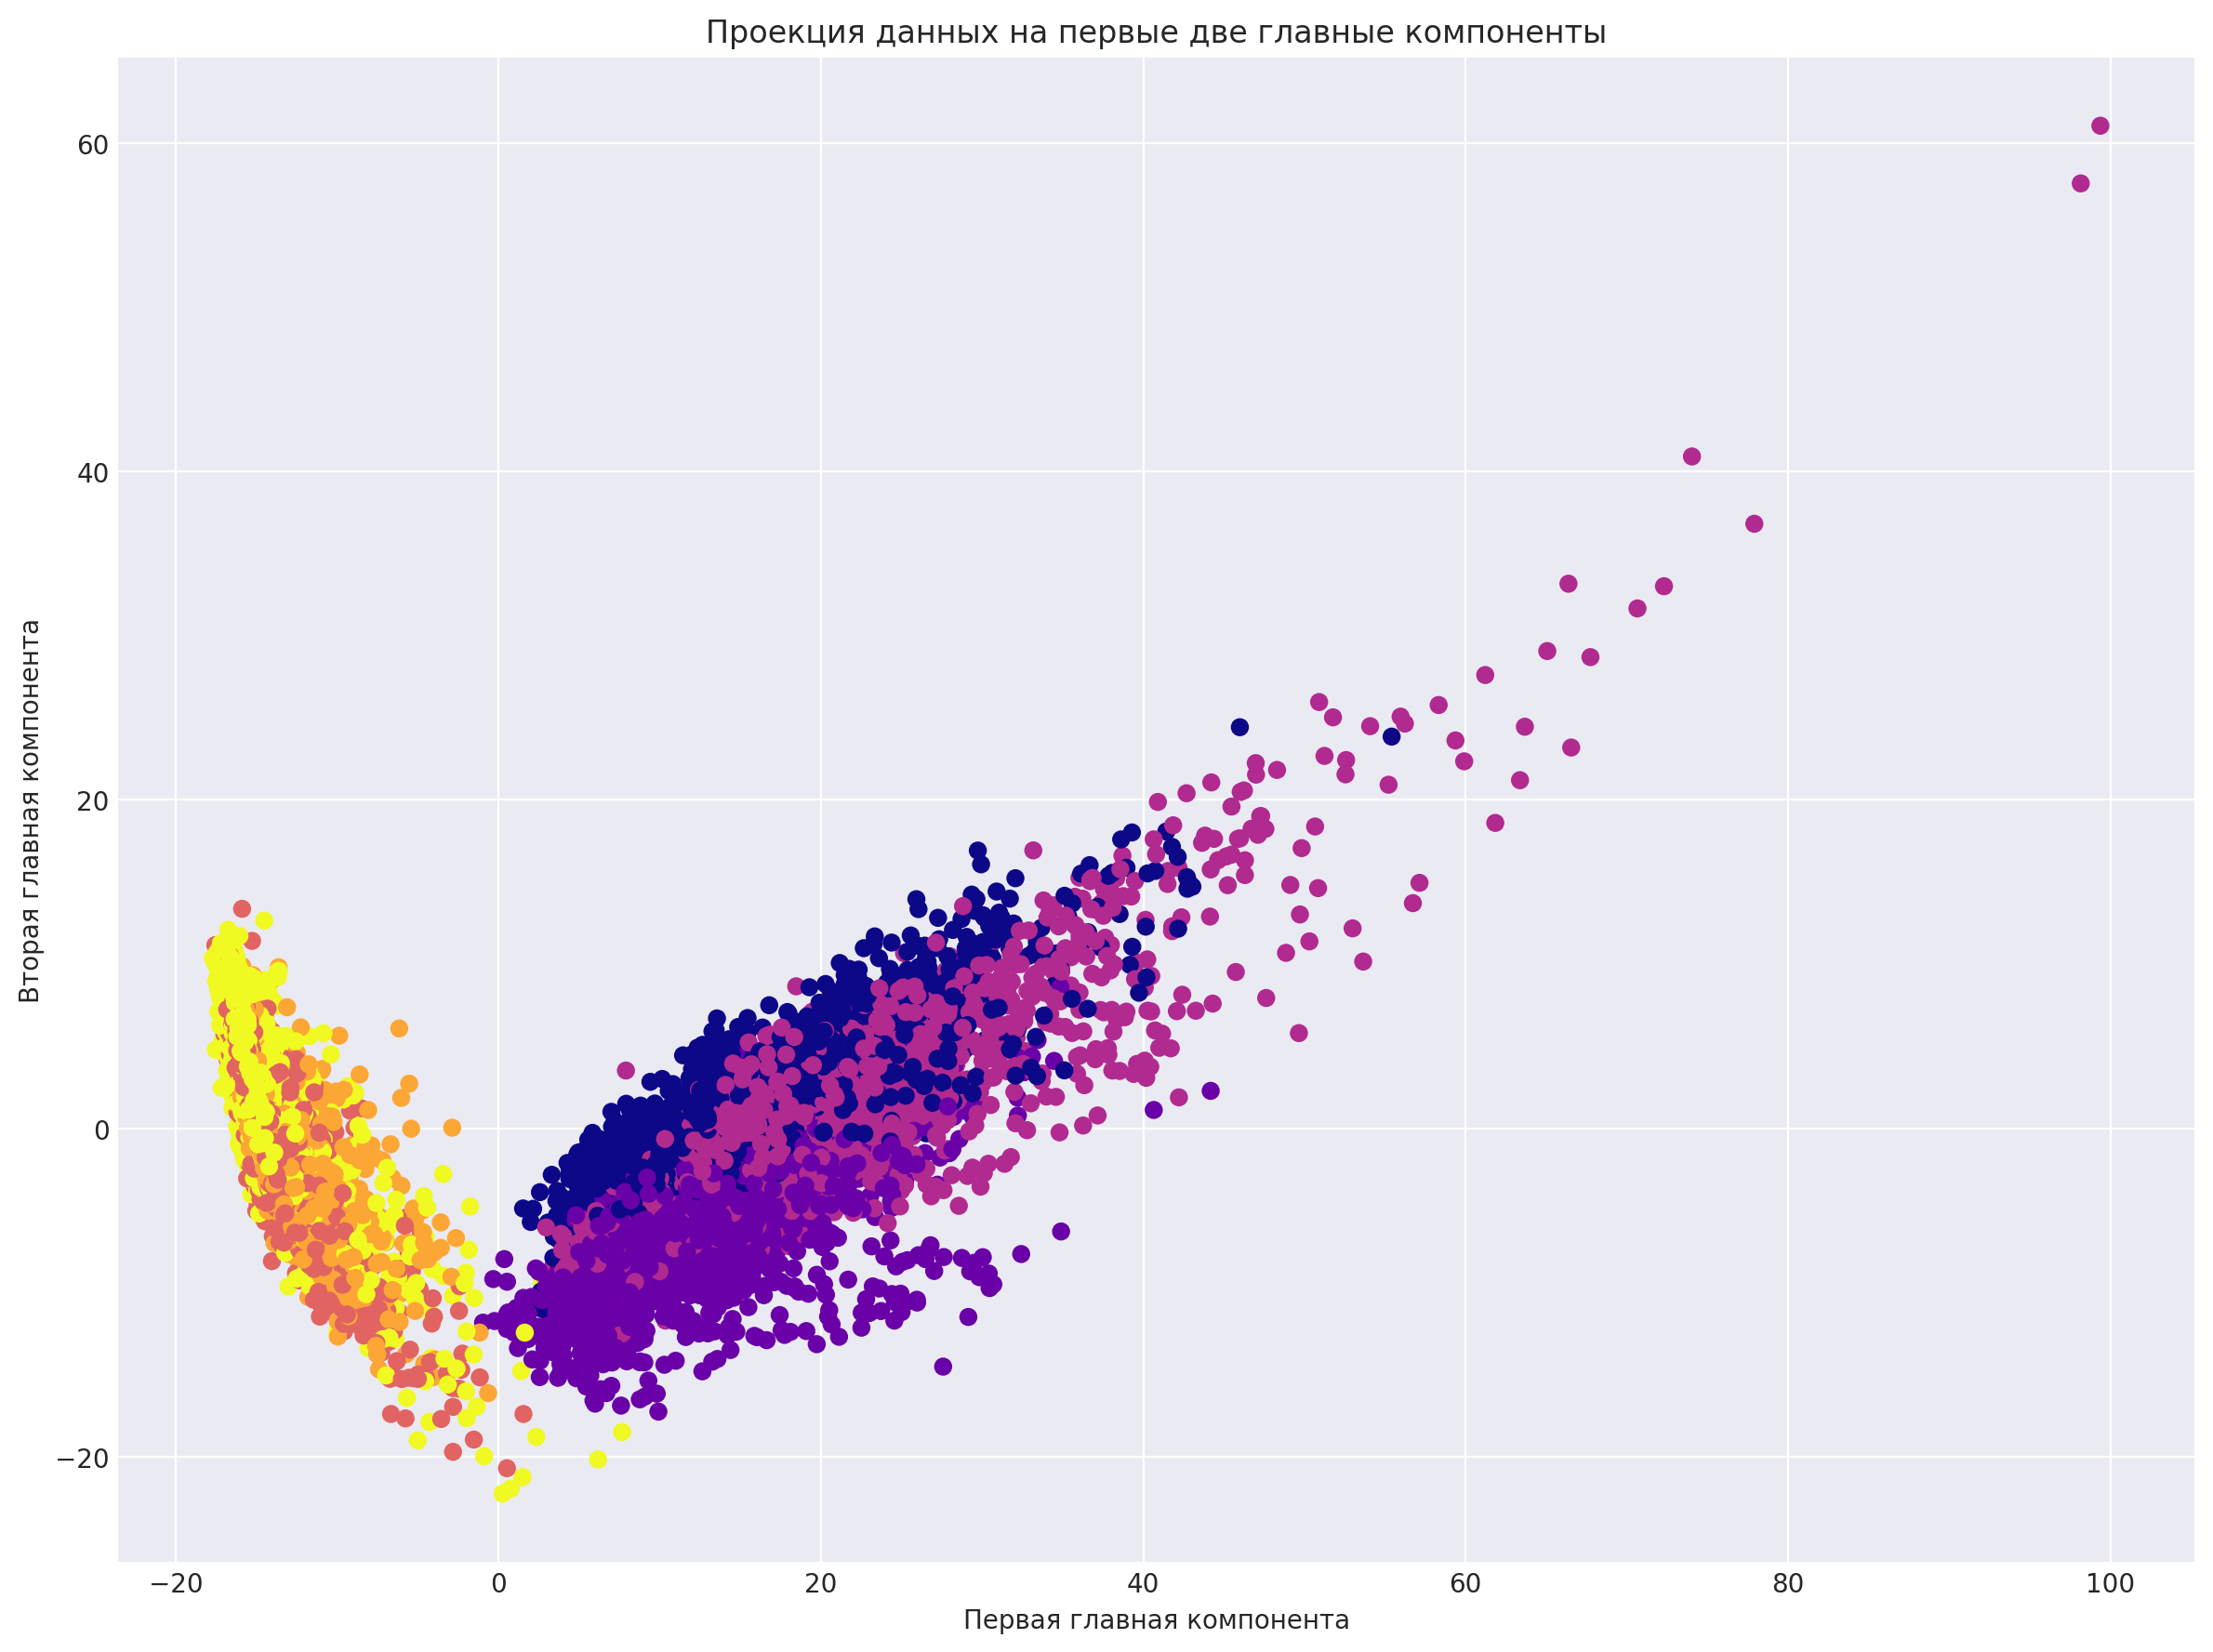

In [139]:
# Ваш код здесь
X_pca_2_comp = X_pca[:, :2]

plt.scatter(X_pca_2_comp[:, 0],
            X_pca_2_comp[:, 1],
            cmap='plasma',
            c=y)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Проекция данных на первые две главные компоненты')
plt.tight_layout()
plt.show()

### **Задание 19. (0.5 балла)**

Разберёмся с `KMeans`, [doc](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

- Сделайте кластеризацию данных методом `KMeans`, обучив модель на данных со сниженной за счет `PCA` размерностью. Нужно искать 6 кластеров (изначально у нас 6 классов). Засеките время обучения и время инференса.

**Параметры обучения:**

```n_clusters = 6``` (число уникальных меток целевого класса = 6)

```n_init = 100```

```random_state = RANDOM_STATE``` (для воспроизводимости результата, не забывайте указывать его и дальше!)

In [140]:
# Ваш код здесь
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42, n_init=100)
kmeans.fit(X_pca)
print(kmeans.labels_)

[2 2 2 ... 3 3 3]


### **Задание 20 (0.2 балла)**

- Визуализируйте данные в проекции на первые две главные компоненты.
- Раскрасьте точки в соответствии с полученными метками кластеров.

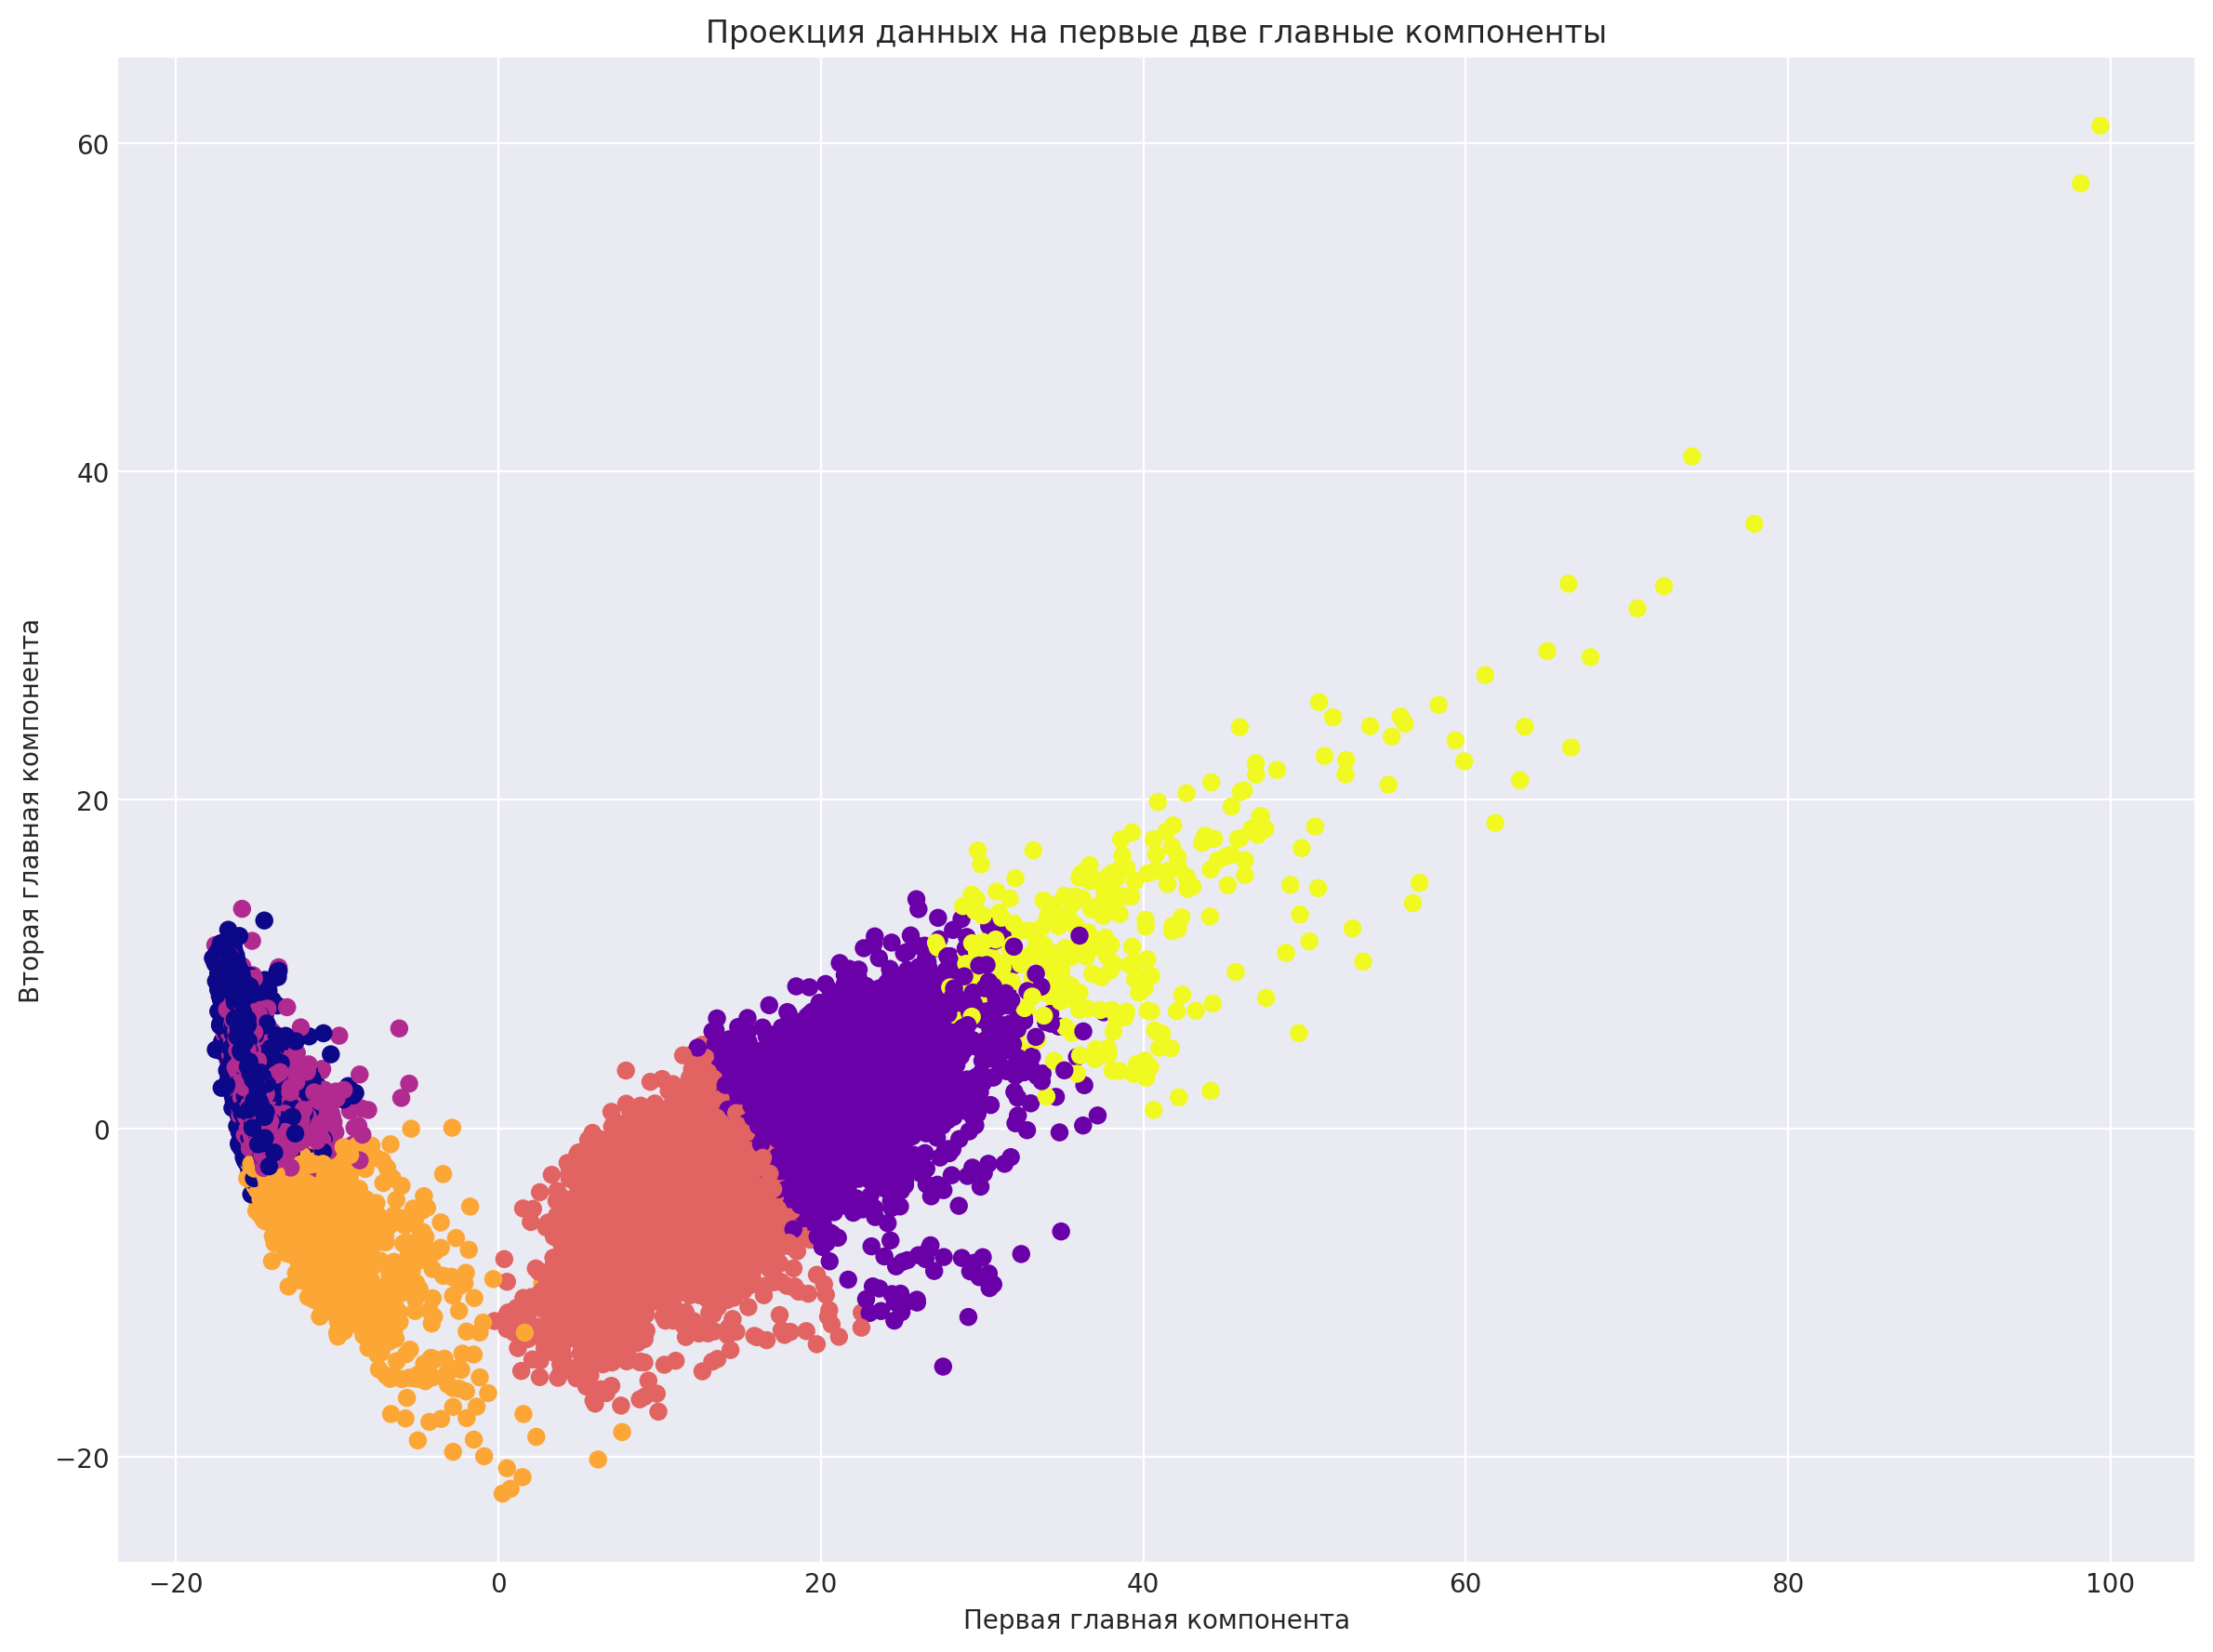

In [141]:
# Ваш код здесь

plt.scatter(X_pca_2_comp[:, 0],
            X_pca_2_comp[:, 1],
            cmap='plasma',
            c=kmeans.labels_)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Проекция данных на первые две главные компоненты')
plt.tight_layout()
plt.show()

### **Задание 21 (0.3 балла)**

- Выберите какие-то метрики (минимум две) из известных вам. Объясните свой выбор
- Выведите на экран значения метрик качества, сделайте вывод о них и используйте их далее.

In [152]:
y_values = pd.to_numeric(y.iloc[:, 0], errors='coerce').values

In [153]:
y_values

array([5, 5, 5, ..., 2, 2, 2])

In [155]:
# Ваш код здесь
from sklearn.metrics import silhouette_score
from sklearn import metrics

print(f"silhouette= {silhouette_score(X_pca, kmeans.labels_)}")
print(f"V-measure= {metrics.v_measure_score(y_values, kmeans.labels_)}")

silhouette= 0.14149759467581466
V-measure= 0.5600410921019029


**Ваш вывод здесь** Я взял две метрики: силуэт и V-меру, потому что силуэт легко интерпретируется, V-мера - среднее между полнотой и гомогенностью, которые используются при размеченных данных. 
По результатам значение силуэта говорит о том, что кластеры в небольшой степени выражены, но все-таки близки к тому, чтобы наложиться. Результат посредственный. V-мера показывает, что соотвествие с истинной разметкой среднее, но не идеальное.

### **Задание 22 (0.7 баллов)**

Теперь попробуем сделать кластеризацию с помощью `AgglomerativeClustering`, [doc](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

- Засеките время обучения и время инференса. После кластеризации также:
  - Вновь визуализируйте данные с раскраской по полученным меткам
  - Выведите метрики. Засеките время обучения и время инференса. Сравните с ```KMeans```.

Ответьте на следующие вопросы:
* Стало ли лучше?
* Почему?

In [156]:
# Ваш код здесь
from sklearn.cluster import AgglomerativeClustering
import time

start = time.time()
aggl = AgglomerativeClustering(n_clusters=6)
aggl.fit(X_pca)
end = time.time()

print(f"Время кластеризации: {end - start:.2f} сек")
print(f"silhouette= {silhouette_score(X_pca, aggl.labels_)}")
print(f"V-measure= {metrics.v_measure_score(y_values, aggl.labels_)}")

Время кластеризации: 2.59 сек
silhouette= 0.13658179879624432
V-measure= 0.6217855076000528


In [ ]:
plt.scatter(X_pca_2_comp[:, 0],
            X_pca_2_comp[:, 1],
            cmap='plasma',
            c=kmeans.labels_)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Проекция данных на первые две главные компоненты')
plt.tight_layout()
plt.show()

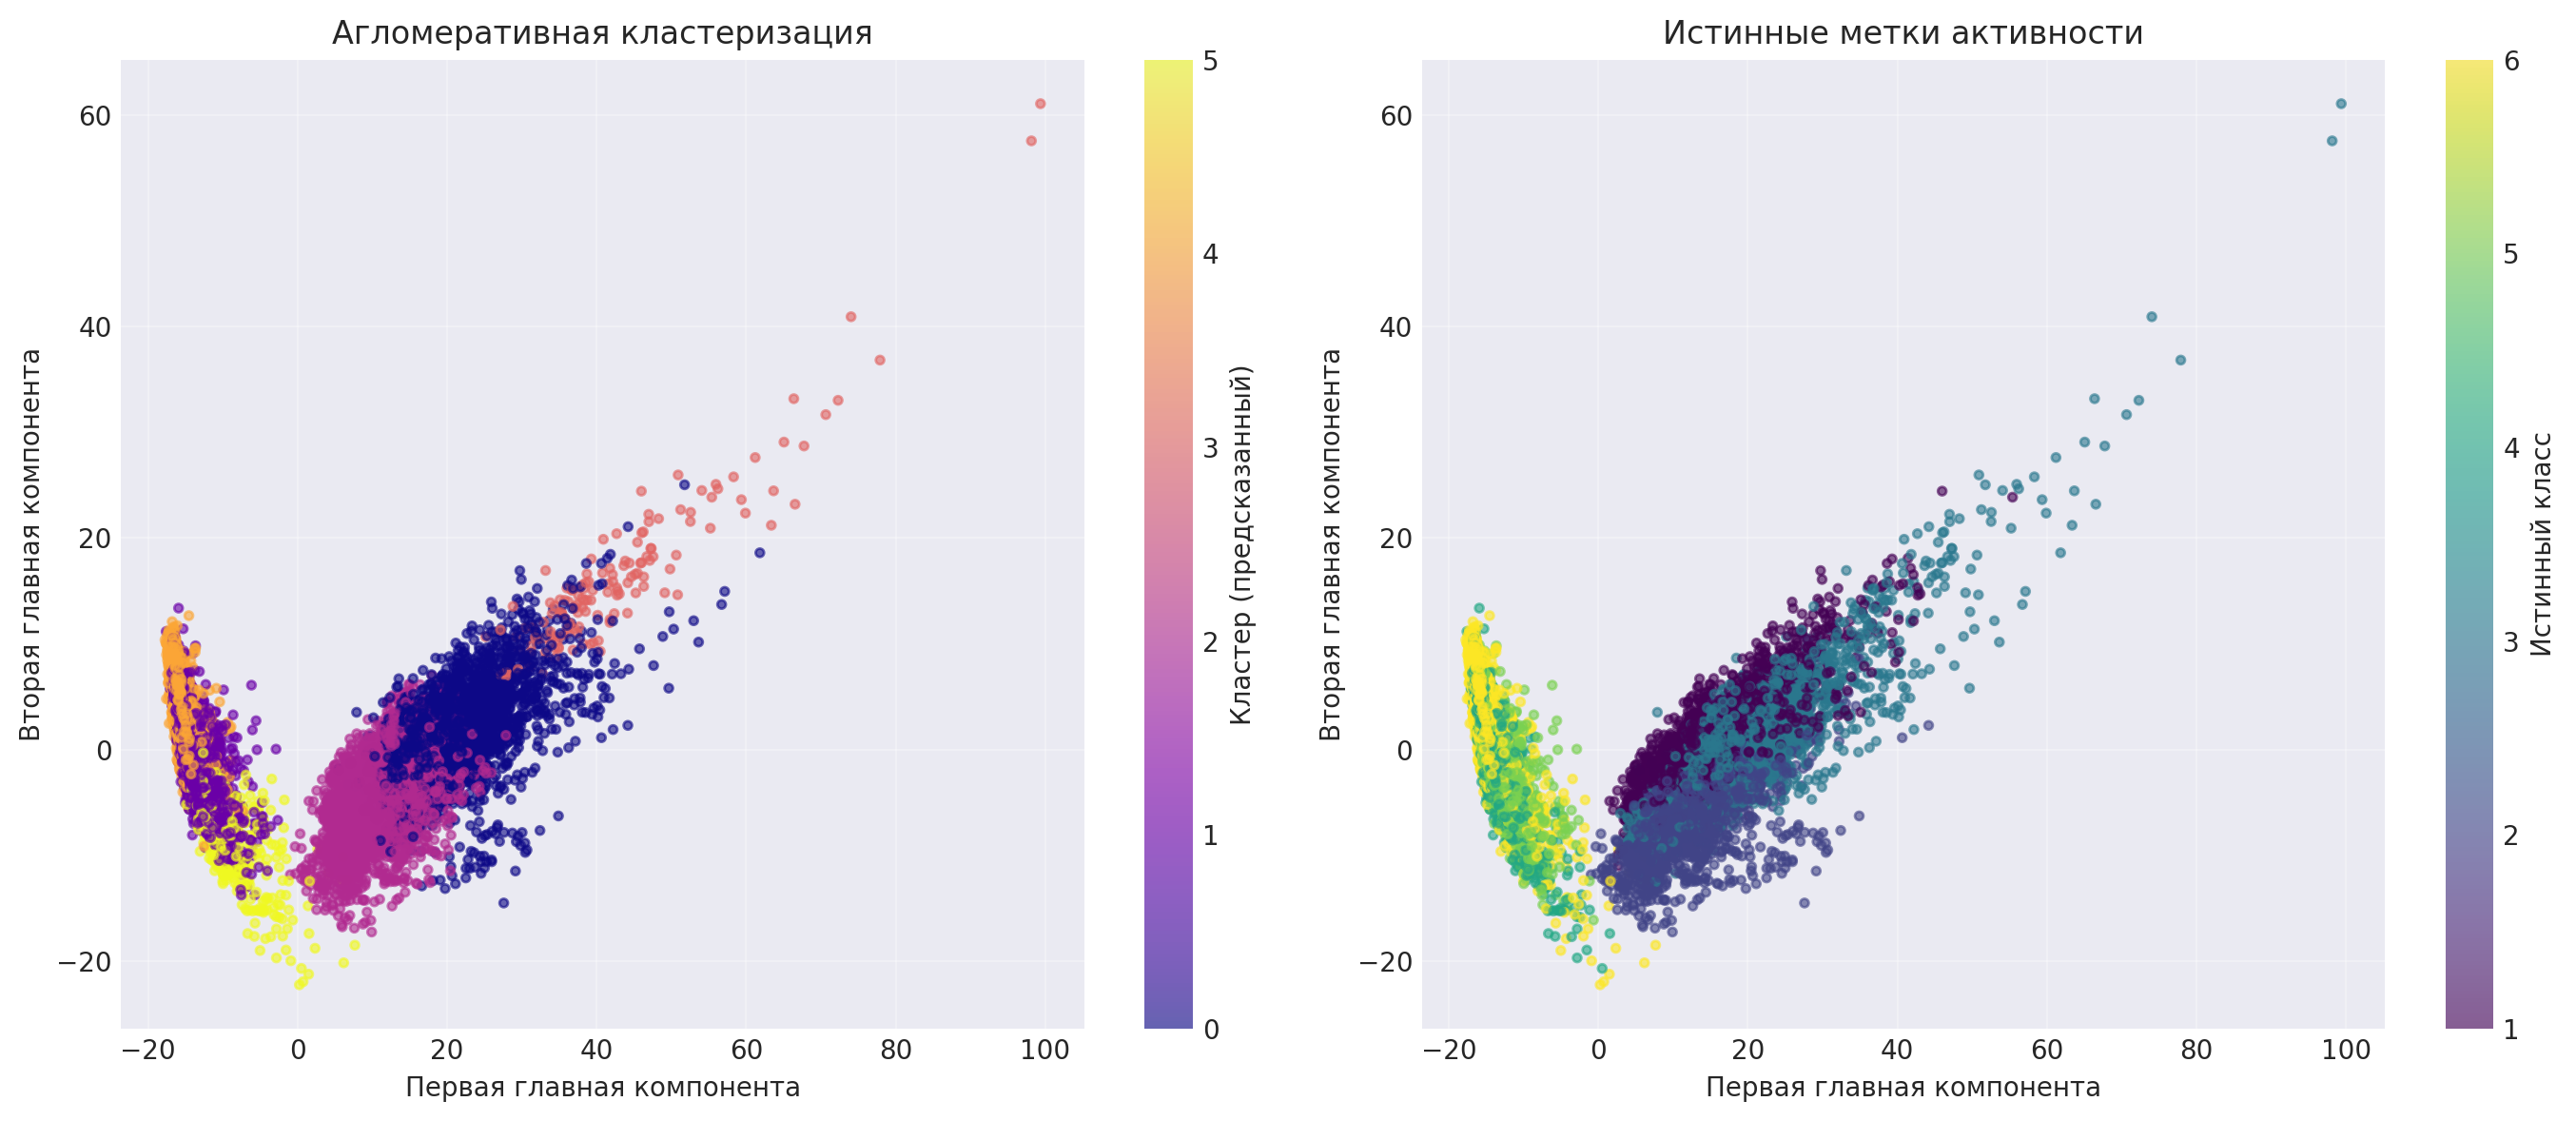

In [158]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_pca[:, 0], 
                       X_pca[:, 1], 
                       c=aggl.labels_, 
                       cmap='plasma', 
                       alpha=0.6, 
                       s=10)
plt.colorbar(scatter1, label='Кластер (предсказанный)')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Агломеративная кластеризация')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_pca[:, 0], 
                       X_pca[:, 1], 
                       c=y, 
                       cmap='viridis', 
                       alpha=0.6, 
                       s=10)
plt.colorbar(scatter2, label='Истинный класс')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Истинные метки активности')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Ваш вывод здесь** Модель ухудшилась в качестве по силуэту. Это значит, что кластеры стали менее разделимыми и компактными, однако качество возрасло согласно V-мере, это значит, что кластеры стали в лучшей степени соотвествовать истинной разметке.

### **Задание 23 (0.3 балла)**
Для самой успешной из полученных кластеризаций попробуйте дать интерпретацию кластеров. Опишите характеристики объектов, попавших в каждый кластер. Для этого можете ответить на следующие вопросы:

* Похожи ли объекты внутри каждого кластера на определенный тип активности человека?
* В каких кластерах смешано несколько типов активности? С чем, на ваш взгляд, это может быть связано?
* Качественная ли получилась кластеризация? На основании чего вы можете сделать такой вывод?

In [166]:
results = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'cluster': aggl.labels_,
    'true_activity': y_values
})

for cluster_num in sorted(results['cluster'].unique()):
    cluster_data = results[results['cluster'] == cluster_num]
    print(f"Кластер {cluster_num} содержит {len(cluster_data)} объектов")
    print("Распределение истинных активностей:")
    print(cluster_data['true_activity'].value_counts().sort_index())

Кластер 0 содержит 2281 объектов
Распределение истинных активностей:
true_activity
1     800
2     337
3    1144
Name: count, dtype: int64
Кластер 1 содержит 3465 объектов
Распределение истинных активностей:
true_activity
4    1559
5    1832
6      74
Name: count, dtype: int64
Кластер 2 содержит 2241 объектов
Распределение истинных активностей:
true_activity
1     896
2    1207
3     138
Name: count, dtype: int64
Кластер 3 содержит 150 объектов
Распределение истинных активностей:
true_activity
1     26
3    124
Name: count, dtype: int64
Кластер 4 содержит 1675 объектов
Распределение истинных активностей:
true_activity
4      71
6    1604
Name: count, dtype: int64
Кластер 5 содержит 487 объектов
Распределение истинных активностей:
true_activity
4    147
5     74
6    266
Name: count, dtype: int64


In [165]:
results

,PC1,PC2,cluster,true_activity
0,-16.380980,1.995083,1,5
1,-15.582173,1.182594,1,5
2,-15.423989,2.243166,1,5
3,-15.647807,3.762882,1,5
4,-15.842320,4.438897,1,5
...,...,...,...,...
10294,10.166057,-6.504223,2,2
10295,12.131154,-4.882447,2,2
10296,11.846853,-3.433565,2,2
10297,8.206686,-4.386489,2,2


**Ваш вывод здесь** Кластер 0 - смесь динамических активностей, то есть ходьба, подъем по лестнице, спуск по лестнице. Кластер 1 - статические активности, сидение, стояние, лежание. кластер 3 - ходьба или спуск по лестнице. кластер 4 - сидение или лежание, кластер 5 - сидение, стояние, лежание.
В целом, практически все кластеры имеют некоторую схожу активность. кластеры 0 и 2 - динамческая активность, 1 и 5 - статическая, 3 и 4 - наиболее чистые кластеры. Возможно, так получилось, потому что поднятие и спуск по лестнице в целом похожие паттерны в данных, так же как сидение и лежание.
Алгоритм правильно разделил динамическую и статическую активности, но внутри этих кластеров разобрался хуже. Так что кластеризация отвечает на глобальный вопрос о детяльности, но плохо уточняет конкрутную деятельность, так что кластеризация среднего качества.

## **Бонус-задание (1 балл)**
![RedPanda](http://imgur.com/6Aa52Lm.png)

Алгоритмы кластеризации могут применяться в самых разных задачах. Например, в анализе изображений есть задача разделения изображения на семантические компоненты, которую можно решать в том числе с помощью алгоритмов кластеризации. В бонусе предлагаем вам попрактиковаться именно в этом на чудесной утке и совах (```duck.jpg``` и ```owls.jpg```)

### **(0.1 балл)**

- Откройте изображения, после чего визуализируйте их с помощью ```plt.imshow()```

In [ ]:
from PIL import Image
# or
#import cv2

### **(0.4 балла)**

Для каждого изображения, используя кластеризацию ```KMeans```, выделите компоненты, охарактеризовав каждый пиксель следующим образом: $$\psi_i = [\lambda x_i, \lambda y_i, r_i, g_i, b_i]$$
 где
- $x_i$ и $y_i$ — координаты пикселя,
- $r_i, g_i, b_i$ — его цвет,
- $\lambda$ — параметр, выражающий важность пространственной связности перед цветовой похожестью.

Примените полученную функцию, взяв следующие $\lambda$: 0.3 и 1.5 для ```duck.jpg``` и ```owls.jpg``` (или другие, но тогда с вас красивые результаты :) )

**Примечание:**
Число кластеров подберите разумным образом на свой вкус (в качестве нулевого приближения можно взять 3)

In [ ]:
def find_components(image, lmbd, n_clusters):
    #your code here

### **(0.4 балла)**

Попробуйте выделить сегменты при помощи [спектральной кластеризации](http://scikit-learn.org/stable/modules/clustering.html#spectral-clustering). Обратите внимание на [пример в sklearn](http://scikit-learn.org/0.16/auto_examples/cluster/plot_lena_segmentation.html).


**Примечание:**

Для ускорения работы алгоритма рекомендуется привести изображение к серому цвету. При необходимости можно сжать изображения в 2 раза.

**Подсказка:**```skimage``` с его ```color``` и ```transform``` в этом помогут :)

Или же воспользуйтесь аналогичными средствами ```PIL``` или ```cv2```

In [ ]:
def spectral_segmentation(image, n_clusters, beta, eps):
    #your code here

### **(0.1 балл)**
Визуализируйте результаты сегментации (аналогично рисунку в начале задания 2) для обоих методов.

**Спасибо! Вы — человек — большой трудяга!**

Успокоительный кот :)

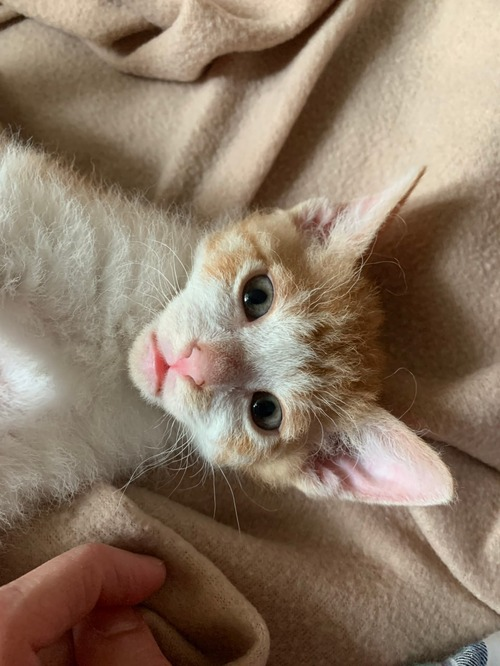